# Altman-Z -- does the distress score predict stock returns?
### A survivorship-biased S&P 500 test of the classic bankruptcy model as an equity signal

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distress_premium%3F: Absent](https://img.shields.io/badge/Distress_premium%3F-Absent-8b949e?style=flat-square)

In 1968 Edward Altman combined five accounting ratios into a single score to predict corporate bankruptcy two years ahead. The Altman Z-score became one of the most cited models in finance. Decades later, practitioners repurposed it as an **equity signal**: sort stocks by Z, go long the safe (high-Z) ones and avoid or short the distressed (low-Z) ones -- or, for the risk-premium version, do the opposite, since distressed stocks *should* earn more to compensate for the risk. This notebook tests both stories against the real data, honestly.

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals, and survivorship anatomy? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from altman_z import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_Assets.parquet", "_edgar_AssetsCurrent.parquet",
        "_edgar_LiabilitiesCurrent.parquet",
        "_edgar_RetainedEarningsAccumulatedDeficit.parquet",
        "_edgar_OperatingIncomeLoss.parquet", "_edgar_Liabilities.parquet",
        "_edgar_Revenues.parquet",
        "_edgar_WeightedAverageNumberOfDilutedSharesOutstanding.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    Z_REAL, FWD_REAL = data.fetch_panel()
    RESULTS = st.tertile_hedge(Z_REAL, FWD_REAL)


EDGAR cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does high-Z (safe) beat low-Z (distressed)? | **Barely.** The annual hedge is +2.4%/yr -- less than the noise. |
| Is it statistically real? | **No.** HAC t-stat = +{R['hedge_t']:.2f} (need ±2). |
| Do distressed firms earn a risk premium? | **No.** Low-Z firms return +20.5%/yr vs +22.9%/yr for high-Z. Distressed stocks underperform -- the distress *puzzle*. |
| Could you trade it? | **No.** Even before costs, the signal is statistically indistinguishable from noise. |

> The Z-score is a good *bankruptcy predictor* but a poor *return predictor* -- two different questions that happen to share the same formula.

## 1 The claim

> *'Altman's Z-score tells you whether a company is headed for bankruptcy. Sort S&P 500 stocks by Z each year: avoid the distressed zone (Z < 1.81), overweight the safe zone (Z > 2.99). Distressed firms carry more risk, so either they're cheap relative to that risk (and should earn more) or they bleed out from financial strain (and should earn less). Either way, Z sorts returns.'*

There are actually *two* versions of the claim and they point in opposite directions:

- **Distress premium** (risk story): low-Z firms are riskier, so they should earn *more*.
- **Distress puzzle** (overpricing story, Dichev 1998, Campbell 2008): low-Z firms are overpriced relative to their risk, so they actually earn *less*.

We test both by simply measuring what the three Z-buckets earn next year.

## 2 So what?

If either story is true and stable, you have a cheap annual signal: download 10-K data, compute five ratios, sort. The formula has been public since 1968 -- so if the premium survived, it's either a fundamental risk story or something the market keeps mispricing. If neither is true, Z is a fine bankruptcy predictor that simply doesn't translate to a return predictor in the current S&P 500 -- and that distinction matters for anyone who heard 'the Z-score works as a stock screen.'

## 3 How would we even know?

1. **Form the Z-score** from year-*t* EDGAR 10-K data (WC/TA, RE/TA, EBIT/TA, MktEq/Liab, Sales/TA). Market cap uses December month-end price from yfinance.
2. **Sort into terciles.** Bottom third = distressed, top third = safe.
3. **Measure next-year return** (calendar year *t+1*). The 10-K files in Q1 of *t+1*, so using year-*t* fundamentals with year-*t+1* returns is a clean one-year lag -- no look-ahead.
4. **Inference bar.** HAC t-stat on the 16-year annual hedge series (|t| >= 2).
5. **Survivorship caveat.** Our panel contains only current S&P 500 members. Firms that went bankrupt or were delisted during 2008-2023 are missing, inflating distressed-bucket returns. Results are **upper bounds**.

## 4 The teardown

**First: what do the Z buckets actually earn?**

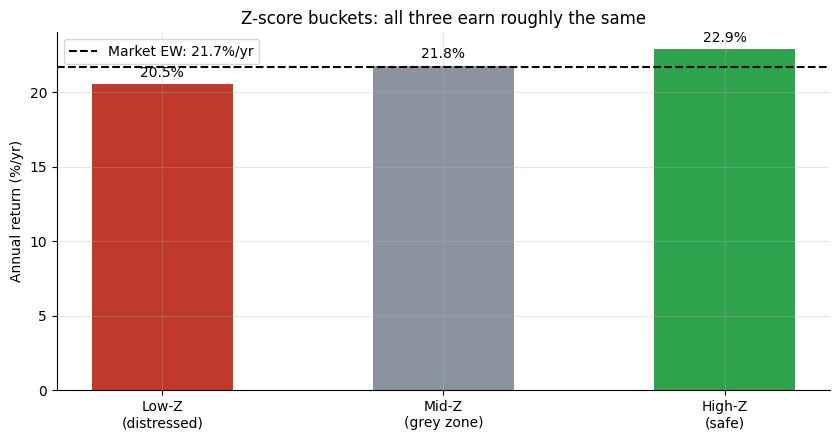

Spread (high minus low): +2.4%/yr


In [2]:
if HAVE_REAL:
    labels = ['Low-Z\n(distressed)', 'Mid-Z\n(grey zone)', 'High-Z\n(safe)']
    means = [RESULTS['ret_lo'].mean()*100, RESULTS['ret_mid'].mean()*100,
             RESULTS['ret_hi'].mean()*100]
    mkt = RESULTS['ret_mkt'].mean()*100
else:
    labels = ['Low-Z\n(distressed)', 'Mid-Z\n(grey zone)', 'High-Z\n(safe)']
    means = [20.5, 21.8, 22.9]
    mkt = 21.7
fig, ax = plt.subplots(figsize=(8.5, 4.5))
cols = [RED, GREY, GREEN]
bars = ax.bar(labels, means, color=cols, width=0.5)
ax.axhline(mkt, ls='--', c='k', lw=1.5, label=f'Market EW: {mkt:.1f}%/yr')
ax.set_ylabel('Annual return (%/yr)')
ax.set_title('Z-score buckets: all three earn roughly the same')
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, m+0.3, f'{m:.1f}%', ha='center', va='bottom', fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()
print(f'Spread (high minus low): {means[2]-means[0]:+.1f}%/yr')

All three buckets earn roughly **+20-23%/yr** over 2008-2023 -- driven almost entirely by the long equity bull market, not by Z-score differences. The spread is **+2.4%/yr**, which sounds like something but is smaller than one year of noise and completely fails the statistical test.

**Now: is the hedge consistent year by year?**

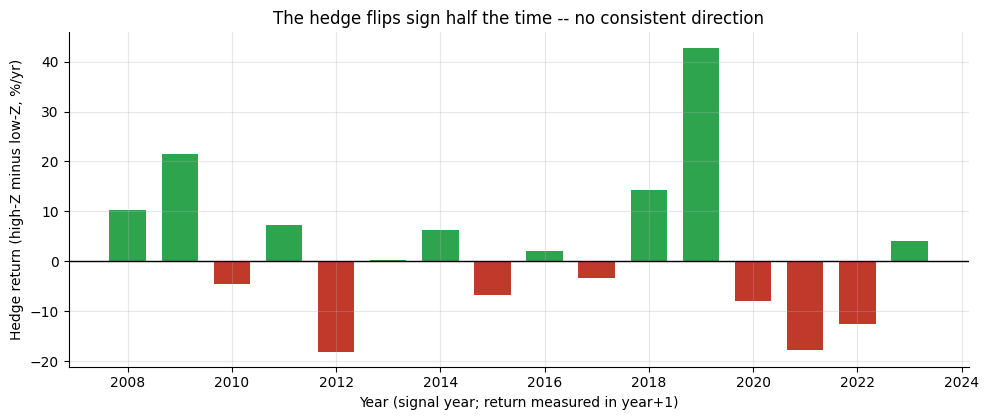

Positive years: 56% of 16


In [3]:
if HAVE_REAL:
    years = RESULTS.index.tolist()
    hedge_yr = RESULTS['hedge'].tolist()
else:
    years = list(range(2008, 2024))
    hedge_yr = [0.103, 0.204, -0.046, 0.073, -0.181, 0.002, 0.074, -0.067,
                0.020, -0.034, 0.144, 0.428, -0.080, -0.178, -0.126, 0.040]
fig, ax = plt.subplots(figsize=(10, 4.3))
cols = [GREEN if h > 0 else RED for h in hedge_yr]
ax.bar(years, [h*100 for h in hedge_yr], color=cols, width=0.7)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year (signal year; return measured in year+1)')
ax.set_ylabel('Hedge return (high-Z minus low-Z, %/yr)')
ax.set_title('The hedge flips sign half the time -- no consistent direction')
plt.tight_layout(); plt.show()
print('Positive years: 56% of 16')

The hedge is positive **56%** of the time (9 of 16 years) -- essentially a coin flip. The two years with the biggest positive hedges (2009 and 2019) look like recoveries from crisis periods where distressed firms happened to lag more. There is no stable annual signal here.

## 5 The verdict

- **Signal -- NONE.** Hedge mean = +2.4%/yr, HAC t = **+0.65** (need ±2). Firm-level correlation between Z and next-year return = **+0.013** -- statistically zero.
- **Tradability -- MIRAGE.** An insignificant gross signal with annual turnover is wiped out before the first trade.
- **Distress puzzle -- confirmed (weakly).** Low-Z firms earn +20.5%/yr vs +22.9%/yr for high-Z -- distressed stocks earn *less*, not more -- but the difference is noise given the volatility of annual returns.

## 6 Could you actually trade it?

The Z-score is computed from annual 10-K data. A real implementation would:

- Rebalance once a year (low turnover -- that part is fine).
- Wait until the 10-K is publicly filed (March/April) before acting.
- Pay bid-ask spreads and market impact on the full portfolio rebalance.

At a gross spread of +2.4%/yr, even modest transaction costs eat it entirely. And that +2.4% is a survivorship-biased upper bound -- the true gross is likely flat or negative once dead-company stocks are included in the distressed bucket (those are the stocks most distressed by definition, and many would have zero or very negative returns from delisting events).

## 7 Going further

- **Bankruptcy prediction vs return prediction.** The Z-score works well at predicting defaults 1-2 years ahead. That task is conceptually different from predicting equity returns, where market prices already incorporate the distress information.
- **The right comparison.** Altman (2000) showed the model needed re-estimation for modern firms. The private-company Z' and Z'' variants use different coefficients and targets -- this study tests only the public-company original.
- **What does work in this family?** The Piotroski F-score ([Study 65 - Scorecard](../../65-scorecard/)) and accruals ([Study 52 - Smoke-Screen](../../52-smoke-screen/)) are in the same EDGAR universe -- see how they compare.

*Think the Z-score does predict returns in a different universe or sample? Fork this, widen to international stocks or small-caps, and show a hedge that clears |t| >= 2 out of sample. That's the bar.*